# Data Understanding
<hr>

## GATE 1: Data Ready
#### Task 1: Source identity, access, and header verification

**Imports**

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load in the data from data folder
df = pd.read_csv('../data/allstate_claims_data.csv')

In [3]:
# CHECK FILE SIZE
actual_size = os.path.getsize('../data/allstate_claims_data.csv')
expected_size = 70025339

print("File size:", actual_size)

if actual_size != expected_size:
    print(f"File size does not match expected: expected {expected_size}, got {actual_size}", "\n")
else:
    print("File size matches", "\n")


# CHECK DF ROWS AND COLUMNS
actual_shape = df.shape
expected_shape = (188318, 132)

print("Rows:", actual_shape[0])
print("Columns:", actual_shape[1])

if actual_shape != expected_shape:
    print(f"df does not match expected rows and columns: expected {expected_shape}, got {actual_shape}")
else:
    print("df matches")

File size: 70025339
File size matches 

Rows: 188318
Columns: 132
df matches


In [4]:
# CHECK HEADERS MATCH
df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


#### Task 2 — Column Roles and Basic Integrity
Assignee: Leng Lim

In [5]:
# CONFIRM COLUMN ROLES
cat_cols = [f"cat{i}" for i in range(1, 117)]
cont_cols = [f"cont{i}" for i in range(1, 15)]

print("Identifier present:", "id" in df.columns)
print("Categorical predictors found:", sum(col in df.columns for col in cat_cols))
print("Continuous predictors found:", sum(col in df.columns for col in cont_cols))
print("Regression target present:", "loss" in df.columns)

Identifier present: True
Categorical predictors found: 116
Continuous predictors found: 14
Regression target present: True


In [6]:

print("ID present:", "id" in df.columns)
print("Missing IDs:", df["id"].isna().sum())
print("Unique IDs:", df["id"].nunique())
print("Total rows:", len(df))
print("All IDs unique:", df["id"].is_unique)

ID present: True
Missing IDs: 0
Unique IDs: 188318
Total rows: 188318
All IDs unique: True


In [7]:
df.isna()
df.isna().sum()
df.isna().sum()
print("Total missing cells:", df.isna().sum().sum())

Total missing cells: 0


In [8]:
df.duplicated()
df.duplicated().sum()
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [9]:
all_numeric = all(
    pd.api.types.is_numeric_dtype(df[col])
    for col in cont_cols
)

all_in_range = (
    (df[cont_cols] >= 0) &
    (df[cont_cols] <= 1)
).all().all()

print("All continuous columns numeric:", all_numeric)
print("All continuous values within 0-1:", all_in_range)


All continuous columns numeric: True
All continuous values within 0-1: True


#### Task 3 — Field Validation and Source Profile


In [10]:
# PART 1 — VALIDATE THE loss TARGET
loss_series = df['loss']
loss_dtype = loss_series.dtype
loss_unique_count = loss_series.nunique(dropna=False)
loss_missing_count = loss_series.isna().sum()
loss_min = loss_series.min()
loss_max = loss_series.max()
loss_non_finite_count = np.isinf(pd.to_numeric(loss_series, errors='coerce')).sum()
loss_non_positive_count = (pd.to_numeric(loss_series, errors='coerce') <= 0).sum()

loss_numeric = pd.api.types.is_numeric_dtype(loss_series)
loss_no_missing = loss_missing_count == 0
loss_no_infinite = loss_non_finite_count == 0
loss_positive = (pd.to_numeric(loss_series, errors='coerce') > 0).all()

print('Loss dtype:', loss_dtype)
print('Loss unique count:', loss_unique_count)
print('Loss missing count:', loss_missing_count)
print('Loss min:', loss_min)
print('Loss max:', loss_max)
print('Loss non-finite count:', loss_non_finite_count)
print('Loss values <= 0:', loss_non_positive_count)
print('Loss numeric:', 'PASS' if loss_numeric else 'FAIL')
print('Loss no missing values:', 'PASS' if loss_no_missing else 'FAIL')
print('Loss no infinite values:', 'PASS' if loss_no_infinite else 'FAIL')
print('Loss strictly positive:', 'PASS' if loss_positive else 'FAIL')

# PART 2 — VALIDATE CATEGORICAL COLUMNS
categorical_profile = pd.DataFrame({
    'column_name': cat_cols,
    'observed_dtype': [df[col].dtype for col in cat_cols],
    'unique_count': [df[col].nunique(dropna=True) for col in cat_cols],
    'missing_count': [df[col].isna().sum() for col in cat_cols],
    'missing_percentage': [df[col].isna().mean() * 100 for col in cat_cols],
})

categorical_profile.head()
print('Categorical profile rows:', len(categorical_profile))
print('Categorical profile sample:')
categorical_profile.head()

# PART 3 — CREATE THE COMPLETE SOURCE PROFILE
roles = {}
for col in df.columns:
    if col == 'id':
        roles[col] = 'identifier'
    elif col in cat_cols:
        roles[col] = 'categorical_predictor'
    elif col in cont_cols:
        roles[col] = 'continuous_predictor'
    elif col == 'loss':
        roles[col] = 'regression_target'
    else:
        roles[col] = 'unknown'

source_profile = pd.DataFrame({
    'column_name': df.columns,
    'role': [roles[col] for col in df.columns],
    'observed_dtype': [df[col].dtype for col in df.columns],
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns],
    'missing_count': [df[col].isna().sum() for col in df.columns],
    'missing_percentage': [df[col].isna().mean() * 100 for col in df.columns],
    'observed_min': np.nan,
    'observed_max': np.nan,
    'expected_scale': [
        'N/A' if col == 'id' else
        'nominal categorical' if col in cat_cols else
        '[0, 1]' if col in cont_cols else
        'positive continuous' if col == 'loss' else
        'unknown'
        for col in df.columns
    ],
})

for col in df.columns:
    if col in cat_cols:
        source_profile.loc[source_profile['column_name'] == col, 'observed_min'] = np.nan
        source_profile.loc[source_profile['column_name'] == col, 'observed_max'] = np.nan
    elif pd.api.types.is_numeric_dtype(df[col]):
        source_profile.loc[source_profile['column_name'] == col, 'observed_min'] = df[col].min()
        source_profile.loc[source_profile['column_name'] == col, 'observed_max'] = df[col].max()
    else:
        source_profile.loc[source_profile['column_name'] == col, 'observed_min'] = np.nan
        source_profile.loc[source_profile['column_name'] == col, 'observed_max'] = np.nan

source_profile.head()
print('Source profile rows:', len(source_profile))
source_profile.head()

# PART 4 — VERIFY THE PROFILE
profile_rows_ok = len(source_profile) == 132
profile_unique_ok = source_profile['column_name'].is_unique
profile_cat_count_ok = (source_profile['role'] == 'categorical_predictor').sum() == 116
profile_cont_count_ok = (source_profile['role'] == 'continuous_predictor').sum() == 14
profile_id_count_ok = (source_profile['role'] == 'identifier').sum() == 1
profile_target_count_ok = (source_profile['role'] == 'regression_target').sum() == 1
profile_roles_ok = (source_profile['role'] != 'unknown').all()
profile_dtype_ok = source_profile['observed_dtype'].notna().all()
profile_missing_ok = source_profile['missing_count'].notna().all()

print('source_profile has exactly 132 rows:', 'PASS' if profile_rows_ok else 'FAIL')
print('each source column appears exactly once:', 'PASS' if profile_unique_ok else 'FAIL')
print('116 categorical predictors represented:', 'PASS' if profile_cat_count_ok else 'FAIL')
print('14 continuous predictors represented:', 'PASS' if profile_cont_count_ok else 'FAIL')
print('1 identifier represented:', 'PASS' if profile_id_count_ok else 'FAIL')
print('1 regression target represented:', 'PASS' if profile_target_count_ok else 'FAIL')
print('every field has a role:', 'PASS' if profile_roles_ok else 'FAIL')
print('every field has dtype information:', 'PASS' if profile_dtype_ok else 'FAIL')
print('every field has missing-value information:', 'PASS' if profile_missing_ok else 'FAIL')

# PART 5 — SAVE MACHINE-READABLE PROFILE
artifacts_dir = '../artifacts'
if not os.path.exists(artifacts_dir):
    os.makedirs(artifacts_dir)

source_profile.to_csv(os.path.join(artifacts_dir, 'source_profile.csv'), index=False)
print('Source profile CSV saved to:', os.path.join(artifacts_dir, 'source_profile.csv'))

# PART 6 — FINAL TASK #3 SUMMARY
loss_numeric_summary = 'PASS' if loss_numeric else 'FAIL'
loss_finite_summary = 'PASS' if loss_no_infinite else 'FAIL'
loss_positive_summary = 'PASS' if loss_positive else 'FAIL'
cat_fields_validated = 'PASS' if len(categorical_profile) == 116 else 'FAIL'
cat_dtype_checks = [
    pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_string_dtype(df[col])
    for col in cat_cols
]
categorical_nominal = 'PASS' if all(cat_dtype_checks) else 'FAIL'
all_fields_profiled = 'PASS' if len(source_profile) == 132 else 'FAIL'
source_profile_generated = 'PASS' if os.path.exists(os.path.join(artifacts_dir, 'source_profile.csv')) else 'FAIL'

print('')
print('Gate 1 — Task #3: Field Validation and Source Profile')
print('Loss numeric:', loss_numeric_summary)
print('Loss finite:', loss_finite_summary)
print('Loss strictly positive:', loss_positive_summary)
print('116 categorical fields validated:', cat_fields_validated)
print('Categorical fields treated as nominal:', categorical_nominal)
print('All 132 fields profiled:', all_fields_profiled)
print('Source profile generated:', source_profile_generated)
print('Total fields profiled:', len(source_profile))
print('Number of categorical fields:', (source_profile['role'] == 'categorical_predictor').sum())
print('Minimum categorical cardinality:', categorical_profile['unique_count'].min())
print('Maximum categorical cardinality:', categorical_profile['unique_count'].max())
print('Top 5 highest-cardinality categorical fields:')
print(categorical_profile.sort_values('unique_count', ascending=False).head(5)[['column_name', 'unique_count']].to_string(index=False))
print('Loss minimum:', loss_min)
print('Loss maximum:', loss_max)
print('Number of fields containing missing values:', int((source_profile['missing_count'] > 0).sum()))

source_profile.head()

Loss dtype: float64
Loss unique count: 158223
Loss missing count: 0
Loss min: 0.67
Loss max: 121012.25
Loss non-finite count: 0
Loss values <= 0: 0
Loss numeric: PASS
Loss no missing values: PASS
Loss no infinite values: PASS
Loss strictly positive: PASS
Categorical profile rows: 116
Categorical profile sample:
Source profile rows: 132
source_profile has exactly 132 rows: PASS
each source column appears exactly once: PASS
116 categorical predictors represented: PASS
14 continuous predictors represented: PASS
1 identifier represented: PASS
1 regression target represented: PASS
every field has a role: PASS
every field has dtype information: PASS
every field has missing-value information: PASS
Source profile CSV saved to: ../artifacts/source_profile.csv

Gate 1 — Task #3: Field Validation and Source Profile
Loss numeric: PASS
Loss finite: PASS
Loss strictly positive: PASS
116 categorical fields validated: PASS
Categorical fields treated as nominal: PASS
All 132 fields profiled: PASS
Sourc

,column_name,role,observed_dtype,unique_count,missing_count,missing_percentage,observed_min,observed_max,expected_scale
0,id,identifier,int64,188318,0,0.0,1.0,587633.0,N/A
1,cat1,categorical_predictor,object,2,0,0.0,NaN,NaN,nominal categorical
2,cat2,categorical_predictor,object,2,0,0.0,NaN,NaN,nominal categorical
3,cat3,categorical_predictor,object,2,0,0.0,NaN,NaN,nominal categorical
4,cat4,categorical_predictor,object,2,0,0.0,NaN,NaN,nominal categorical


#### Task 4 - Anomaly Register, Workflow Run and Verification


In [ ]:
### Task #7 — Categorical-Analysis Method

This section freezes the categorical EDA protocol for the 116 `cat*` fields. I will treat all `cat*` variables as nominal and will not create arbitrary numeric codes for association analysis. The rare-level cutoff is a display and support rule for making high-cardinality plots readable; it is not an instruction to remove or merge levels.

- Rare-level threshold: support < 100 claims
- Low-cardinality display threshold: <= 10 unique levels
- High-cardinality display threshold: > 10 unique levels
- Categorical summaries remain in the original field values and original `loss` units.

"# Freeze the categorical EDA thresholds used in this notebook\nrare_level_threshold = 100\nlow_cardinality_display_threshold = 10\n\nrare_level_rationale = (\n    \"A category is rare when it appears in fewer than 100 claims. \"\n    \"This is a display and support rule for readable EDA, not an instruction to remove, \"\n    \"merge, or re-code the level.\"\n)\n\nprint(\"Rare-level threshold:\", rare_level_threshold)\nprint(\"Low-cardinality display threshold:\", low_cardinality_display_threshold)\nprint(\"Rationale:\", rare_level_rationale)\n"
"# Freeze an inventory for all 116 cat* features\ncategorical_inventory_rows = []\nfor col in cat_cols:\n    counts = df[col].value_counts(dropna=False)\n    support_values = counts.to_numpy()\n    field_record = {\n        \"column_name\": col,\n        \"cardinality\": int(counts.shape[0]),\n        \"most_common_level\": counts.index[0],\n        \"least_common_level\": counts.index[-1],\n        \"most_common_level_support\": int(counts.iloc[0]),\n        \"least_common_level_support\": int(counts.iloc[-1]),\n        \"most_common_level_share\": float(counts.iloc[0] / len(df)),\n        \"min_level_support\": int(support_values.min()),\n        \"median_level_support\": float(np.median(support_values)),\n        \"levels_below_rare_threshold\": int((counts < rare_level_threshold).sum()),\n        \"rare_level_threshold\": rare_level_threshold,\n        \"cardinality_group\": \"low\" if counts.shape[0] <= low_cardinality_display_threshold else \"high\",\n    }\n    categorical_inventory_rows.append(field_record)\n\ncategorical_inventory = pd.DataFrame(categorical_inventory_rows)\ncategorical_inventory = categorical_inventory[\n    [\"column_name\",\"cardinality\",\"most_common_level\",\"least_common_level\",\n     \"most_common_level_support\",\"least_common_level_support\",\"most_common_level_share\",\n     \"min_level_support\",\"median_level_support\",\"levels_below_rare_threshold\",\n     \"rare_level_threshold\",\"cardinality_group\"]\n].sort_values(\"column_name\").reset_index(drop=True)\n\ncategorical_inventory.to_csv(os.path.join(artifacts_dir, \"categorical_inventory.csv\"), index=False)\nprint(\"Categorical inventory saved to:\", os.path.join(artifacts_dir, \"categorical_inventory.csv\"))\nprint(\"Rows in categorical_inventory:\", len(categorical_inventory))\nprint(\"Low-cardinality fields:\", int((categorical_inventory[\"cardinality_group\"] == \"low\").sum()))\nprint(\"High-cardinality fields:\", int((categorical_inventory[\"cardinality_group\"] == \"high\").sum()))\ncategorical_inventory.head()\n"
"# Freeze level-to-target tables for each cat* field\nlevel_target_rows = []\nfor col in cat_cols:\n    grouped = df.groupby(col, dropna=False)[\"loss\"].agg(\n        level_support=\"count\",\n        raw_mean_loss=\"mean\",\n        raw_median_loss=\"median\",\n        raw_loss_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),\n    ).reset_index()\n    grouped.columns = [\"level\", \"level_support\", \"raw_mean_loss\", \"raw_median_loss\", \"raw_loss_iqr\"]\n    grouped[\"field_name\"] = col\n    grouped[\"rare_level_flag\"] = grouped[\"level_support\"] < rare_level_threshold\n    grouped[\"log1p_mean_loss\"] = np.log1p(grouped[\"raw_mean_loss\"])\n    grouped[\"log1p_median_loss\"] = np.log1p(grouped[\"raw_median_loss\"])\n    level_target_rows.append(grouped[[\"field_name\",\"level\",\"level_support\",\"raw_mean_loss\",\"raw_median_loss\",\"raw_loss_iqr\",\"rare_level_flag\",\"log1p_mean_loss\",\"log1p_median_loss\"]])\n\ncategorical_level_target = pd.concat(level_target_rows, ignore_index=True)\ncategorical_level_target = categorical_level_target.sort_values([\"field_name\",\"level_support\"], ascending=[True, False]).reset_index(drop=True)\n\ncategorical_level_target.to_csv(os.path.join(artifacts_dir, \"categorical_level_target.csv\"), index=False)\nprint(\"Level-to-target table saved to:\", os.path.join(artifacts_dir, \"categorical_level_target.csv\"))\nprint(\"Rows in categorical_level_target:\", len(categorical_level_target))\nprint(\"Minimum support in level target:\", categorical_level_target[\"level_support\"].min())\nprint(\"Median support in level target:\", categorical_level_target[\"level_support\"].median())\nprint(\"Rare-level rows:\", int(categorical_level_target[\"rare_level_flag\"].sum()))\ncategorical_level_target.head()\n"
"# Example categorical views for a low-cardinality and a high-cardinality field\nimport seaborn as sns\n\nsns.set_theme(style=\"whitegrid\")\n\nlow_field = categorical_inventory.loc[categorical_inventory[\"cardinality_group\"] == \"low\", \"column_name\"].iloc[0]\nhigh_field = categorical_inventory.sort_values(\"cardinality\", ascending=False)[\"column_name\"].iloc[0]\n\nlow_field_table = (\n    categorical_level_target[categorical_level_target[\"field_name\"] == low_field]\n    .sort_values(\"level_support\", ascending=False)\n    .reset_index(drop=True)\n)\nhigh_field_table = (\n    categorical_level_target[categorical_level_target[\"field_name\"] == high_field]\n    .sort_values(\"level_support\", ascending=False)\n    .reset_index(drop=True)\n)\n\nprint(\"Example low-cardinality field:\", low_field)\nprint(low_field_table[[\"level\",\"level_support\",\"raw_mean_loss\",\"raw_median_loss\",\"raw_loss_iqr\"]].head(10).to_string(index=False))\nprint(\"\")\nprint(\"Example high-cardinality field:\", high_field)\nprint(\"Supported levels (>= rare threshold):\", int((high_field_table[\"level_support\"] >= rare_level_threshold).sum()))\nprint(\"Rare tail levels (< rare threshold):\", int((high_field_table[\"level_support\"] < rare_level_threshold).sum()))\nprint(high_field_table[high_field_table[\"level_support\"] >= rare_level_threshold][[\"level\",\"level_support\",\"raw_mean_loss\",\"raw_median_loss\",\"raw_loss_iqr\"]].head(10).to_string(index=False))\n\n# Plot the low-cardinality example with log1p(loss)\nplt.figure(figsize=(10, 5))\nsns.boxplot(\n    data=df,\n    x=low_field,\n    y=np.log1p(df[\"loss\"]),\n    order=low_field_table[\"level\"].tolist()\n)\nplt.title(f\"Example low-cardinality view: {low_field} vs log1p(loss)\")\nplt.ylabel(\"log1p(loss)\")\nplt.xlabel(low_field)\nplt.xticks(rotation=45)\nplt.show()\n\n# High-cardinality fields remain in compact ordered summaries rather than dense label-heavy plots\nprint(\"High-cardinality summary view is intentionally compact and sorted by support.\")\nprint(high_field_table[[\"level\",\"level_support\",\"raw_mean_loss\",\"raw_median_loss\",\"raw_loss_iqr\"]].head(15).to_string(index=False))\n"

In [11]:

import datetime
import platform
import sys

# Programmatic Verification of Integrity Checks from Gate 1
audit_results = {}

# Check dataset
audit_results["file_size_bytes"] = os.path.getsize(
    "../data/allstate_claims_data.csv"
)
audit_results["row_count"] = len(df)
audit_results["column_count"] = len(df.columns)
audit_results["unique_id_count"] = df["id"].nunique()
audit_results["missing_cell_count"] = int(df.isna().sum().sum())
audit_results["duplicate_row_count"] = int(df.duplicated().sum())

# Check actual data values
audit_results["cont_in_bounds"] = bool(
    ((df[cont_cols] >= 0) & (df[cont_cols] <= 1)).all().all()
)
audit_results["loss_strictly_positive"] = bool((df["loss"] > 0).all()) # Loss must be positive
audit_results["artifact_profile_exists"] = os.path.exists(
    "../artifacts/source_profile.csv"
)

# Assertion checks
assert (
    audit_results["file_size_bytes"] == 70025339
), "FAIL: File size mismatch"
assert audit_results["row_count"] == 188318, "FAIL: Row count mismatch"
assert audit_results["column_count"] == 132, "FAIL: Column count mismatch"
assert (
    audit_results["unique_id_count"] == 188318
), "FAIL: Non-unique IDs detected"
assert (
    audit_results["missing_cell_count"] == 0
), "FAIL: Missing values detected"
assert audit_results["duplicate_row_count"] == 0, "FAIL: Duplicate rows detected"
assert audit_results[
    "cont_in_bounds"
], "FAIL: Continuous variables out of [0, 1]"
assert audit_results[
    "loss_strictly_positive"
], "FAIL: Non-positive loss values found"
assert audit_results[
    "artifact_profile_exists"
], "FAIL: Source profile artifact missing"

print("--- GATE 1 PROGRAMMATIC AUDIT: ALL CHECKS PASSED ---")
for check, status in audit_results.items():
  print(f"{check}: {status}")

# Workflow run metadata execution reciept
print("\n--- WORKFLOW RUN EXECUTION RECEIPT ---")
print("Execution Timestamp:", datetime.datetime.now().isoformat())
print("Python Version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)

--- GATE 1 PROGRAMMATIC AUDIT: ALL CHECKS PASSED ---
file_size_bytes: 70025339
row_count: 188318
column_count: 132
unique_id_count: 188318
missing_cell_count: 0
duplicate_row_count: 0
cont_in_bounds: True
loss_strictly_positive: True
artifact_profile_exists: True

--- WORKFLOW RUN EXECUTION RECEIPT ---
Execution Timestamp: 2026-09-19T11:13:41.165360
Python Version: 3.14.2
Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
Pandas Version: 2.3.3
NumPy Version: 2.4.1


<hr>

## Gate 2: EDA Scope and Methods Frozen
#### Task 1: Analysis Contract and Target-Analysis Method

**Analysis Contract**
1. The goal of this project is to estimate a claim's final paid amount early enough to support reserve planning and better understand which factors are associated with higher claim severity. Reserve planning means estimating how much money an insurance company should set aside in advance to cover the expected future cost of claims.
2. The unit of analysis is one auto insurance claim represented by one row in the delivered dataset.
3. The target we are trying to predict is `loss`, so this is a regression problem. I will keep `loss` in its original units when reporting results and when evaluating the model later.
4. The project success metric is Mean Absolute Error (MAE). MAE tells us, on average, how far the model's predicted `loss` is from the actual `loss`. Absolute error only looks at the size of the difference, so predicting too high or too low is treated the same way.
    **Mean Absolute Error:**

    $$
    MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
    $$

    Where:
    - $n$ = number of claims
    - $y_i$ = actual loss
    - $\hat{y}_i$ = predicted loss
    - $|y_i - \hat{y}_i|$ = absolute error for one claim

5. According to the project overview, closed claims without payment are excluded. For the delivered dataset, I will only verify that all `loss` values are positive and will not assume why any individual claim is included in the data.

In [12]:
print((loss_series > 0).all())

True



6. The specific meanings of the `cat*` and `cont*` fields are unknown. The project overview gives examples of possible field types, but those examples do not tell us which real-world meaning belongs to each specific column.
7. This September EDA is only for exploring patterns in the data and defining our analysis approach. It does not prove that any feature causes higher claim severity, determine the reserve for an individual claim, prove that the model is production-ready, or authorize automated claims decisions.
8. For the target analysis, I will use one fixed summary of `loss` that includes count, mean, median, standard deviation, minimum, maximum, skewness, and the 25th, 50th, 75th, 90th, 95th, and 99th percentiles.

In [13]:
loss_summary = loss_series.describe(
      percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

loss_skewness = loss_series.skew()

print("==================")

print("Loss Summary Statistics:")
print(loss_summary)
print("Skewness:", loss_skewness)
print("The 50th percentile is also the median:", loss_series.median())

Loss Summary Statistics:
count    188318.000000
mean       3037.337686
std        2904.086186
min           0.670000
25%        1204.460000
50%        2115.570000
75%        3864.045000
90%        6401.743000
95%        8508.536500
99%       13981.203000
max      121012.250000
Name: loss, dtype: float64
Skewness: 3.7949583775378586
The 50th percentile is also the median: 2115.5699999999997


9. For the target analysis, I will use four fixed views of `loss`: a raw `loss` histogram, a `log1p(loss)` histogram, a raw `loss` boxplot, and a compact percentile table in the original loss units.

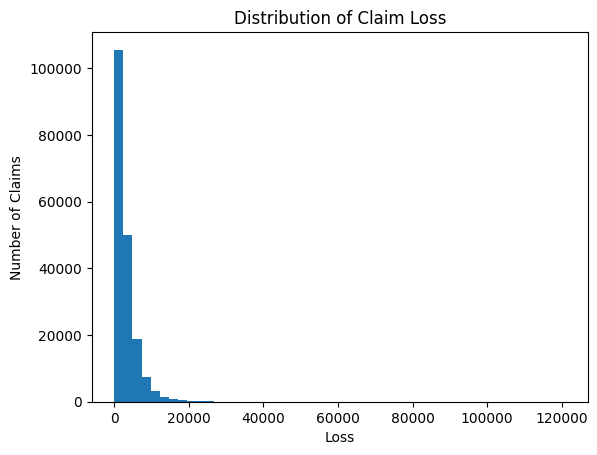

In [14]:
import matplotlib.pyplot as plt

# raw loss histogram
plt.hist(loss_series, bins=50)
plt.xlabel("Loss")
plt.ylabel("Number of Claims")
plt.title("Distribution of Claim Loss")
plt.show()

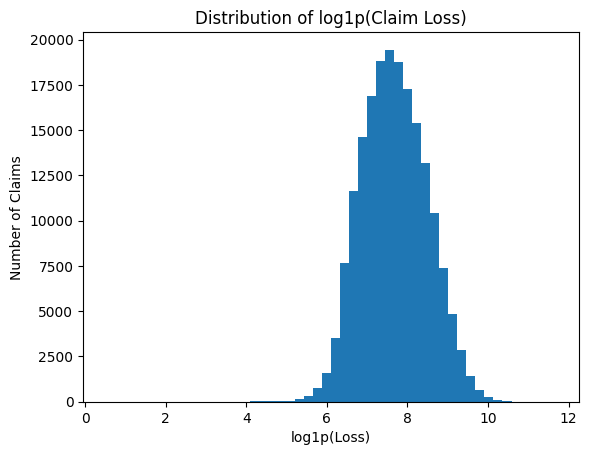

In [15]:
# log1p(loss) histogram
log1p_loss = np.log1p(loss_series)

plt.hist(log1p_loss, bins=50)
plt.xlabel("log1p(Loss)")
plt.ylabel("Number of Claims")
plt.title("Distribution of log1p(Claim Loss)")
plt.show()

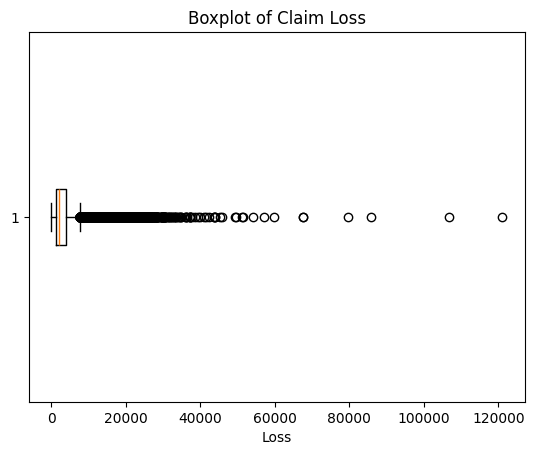

In [16]:
# raw loss boxplot
plt.boxplot(loss_series, vert=False)
plt.xlabel("Loss")
plt.title("Boxplot of Claim Loss")
plt.show()

In [17]:
# percentile table
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

percentile_table = pd.DataFrame({
    "Percentile": ["25th", "50th", "75th", "90th", "95th", "99th"],
    "Loss": [loss_series.quantile(p) for p in percentiles]
})

percentile_table["Loss"] = percentile_table["Loss"].round(2)
percentile_table

,Percentile,Loss
0,25th,1204.46
1,50th,2115.57
2,75th,3864.04
3,90th,6401.74
4,95th,8508.54
5,99th,13981.20


10. For the target plots, I will use 50 bins for both histograms and use the full dataset without sampling. The raw `loss` histogram and boxplot will stay in the original loss scale, while the second histogram will use `log1p(loss)`. I will not clip the distributions, so all observed loss values remain represented.
11. I will use `log1p(loss)` only to make the target distribution easier to visualize. It does not replace the original `loss` target, and future MAE calculations will still be performed using the original loss values.

#### Task 2: Project-specific Data Dictionary

In [18]:
import os
import pandas as pd

SRC = "../data/allstate_claims_data.csv"
OUT_DIR = "../artifacts"
VERSION = "v1.0.0"
OWNER = "Leng" 

cat_cols = [f"cat{i}" for i in range(1, 117)]
df = pd.read_csv(SRC, dtype={c: "string" for c in cat_cols})

# Fixed text by role
ROLES = {
    "id": ("identifier", "N/A", "Claim row identifier",
           "Integrity checks only; excluded from distribution and target-effect interpretation"),
    "cat": ("categorical predictor", "N/A (anonymous nominal)", "Unknown",
            "Unordered nominal labels; no causal interpretation"),
    "cont": ("continuous predictor", "Scaled 0 to 1; original unit unknown", "Unknown",
             "Profile on delivered scale"),
    "loss": ("target", "Original loss units", "Total paid claim amount",
             "Positive continuous target; never replaced by log1p_loss"),
}

rows = []
for col in df.columns:
    key = "cat" if col.startswith("cat") else "cont" if col.startswith("cont") else col
    role, unit, meaning, handling = ROLES[key]
    s = df[col]
    if key == "cat":
        dtype, rng = "category label", "|".join(sorted(s.dropna().unique()))
    else:
        dtype, rng = str(s.dtype), f"{s.min():.6g} to {s.max():.6g}"
    rows.append({
        "field": col, "field_type": "source", "role": role,
        "observed_dtype": dtype, "range_or_levels": rng,
        "unique_count": s.nunique(), "missing_count": s.isna().sum(),
        "missing_pct": 100 * s.isna().mean(), "unit_or_scale": unit,
        "documented_meaning": meaning,
        "quality_limitation": "None recorded in anomaly register",
        "september_handling": handling,
        "purpose": "", "inputs": "", "derivation": "",
        "version": VERSION, "owner": OWNER,
    })

# Derived fields
rows.append({
    "field": "log1p_loss", "field_type": "derived", "role": "derived (visualization only)",
    "observed_dtype": "float64", "range_or_levels": "finite, > 0",
    "purpose": "Visualization only; never replaces loss or MAE scale",
    "inputs": "loss", "derivation": "np.log1p(loss)",
    "september_handling": "Plots only", "version": VERSION, "owner": OWNER,
})

dictionary = pd.DataFrame(rows)

os.makedirs(OUT_DIR, exist_ok=True)
dictionary.to_csv(f"{OUT_DIR}/data_dictionary_{VERSION}.csv", index=False)

assert (dictionary["field_type"] == "source").sum() == 132
print(dictionary["role"].value_counts())

role
categorical predictor           116
continuous predictor             14
identifier                        1
target                            1
derived (visualization only)      1
Name: count, dtype: int64


In [20]:
data_dictionary = pd.read_csv("../artifacts/data_dictionary_v1.0.0.csv")
data_dictionary

,field,field_type,role,observed_dtype,range_or_levels,unique_count,missing_count,missing_pct,unit_or_scale,documented_meaning,quality_limitation,september_handling,purpose,inputs,derivation,version,owner
0,id,source,identifier,int64,1 to 587633,188318.0,0.0,0.0,NaN,Claim row identifier,None recorded in anomaly register,Integrity checks only; excluded from distribut...,NaN,NaN,NaN,v1.0.0,Leng
1,cat1,source,categorical predictor,category label,A|B,2.0,0.0,0.0,N/A (anonymous nominal),Unknown,None recorded in anomaly register,Unordered nominal labels; no causal interpreta...,NaN,NaN,NaN,v1.0.0,Leng
2,cat2,source,categorical predictor,category label,A|B,2.0,0.0,0.0,N/A (anonymous nominal),Unknown,None recorded in anomaly register,Unordered nominal labels; no causal interpreta...,NaN,NaN,NaN,v1.0.0,Leng
3,cat3,source,categorical predictor,category label,A|B,2.0,0.0,0.0,N/A (anonymous nominal),Unknown,None recorded in anomaly register,Unordered nominal labels; no causal interpreta...,NaN,NaN,NaN,v1.0.0,Leng
4,cat4,source,categorical predictor,category label,A|B,2.0,0.0,0.0,N/A (anonymous nominal),Unknown,None recorded in anomaly register,Unordered nominal labels; no causal interpreta...,NaN,NaN,NaN,v1.0.0,Leng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,cont12,source,continuous predictor,float64,0.036232 to 0.998484,328.0,0.0,0.0,Scaled 0 to 1; original unit unknown,Unknown,None recorded in anomaly register,Profile on delivered scale,NaN,NaN,NaN,v1.0.0,Leng
129,cont13,source,continuous predictor,float64,0.000228 to 0.988494,353.0,0.0,0.0,Scaled 0 to 1; original unit unknown,Unknown,None recorded in anomaly register,Profile on delivered scale,NaN,NaN,NaN,v1.0.0,Leng
130,cont14,source,continuous predictor,float64,0.179722 to 0.844848,18740.0,0.0,0.0,Scaled 0 to 1; original unit unknown,Unknown,None recorded in anomaly register,Profile on delivered scale,NaN,NaN,NaN,v1.0.0,Leng
131,loss,source,target,float64,0.67 to 121012,158223.0,0.0,0.0,Original loss units,Total paid claim amount,None recorded in anomaly register,Positive continuous target; never replaced by ...,NaN,NaN,NaN,v1.0.0,Leng
